<font color='blue'> **07 grid3Dinput** </font>

In [1]:
from importlib.metadata import entry_points ; import numpy as np  ; import matplotlib.pyplot as plt     ; import pyvista as pv      ; import os
from fipy import input  ; from fipy import CellVariable, Grid2D, Grid3D, DiffusionTerm, Viewer          ; from fipy.tools import numerix
import warnings;warnings.filterwarnings("ignore", category=UserWarning)                               # ; from mayavi import mlab

In [2]:
nx  = 8 ; ny = 5  ; nz = 3   ; dx = 1. ;dy = 1.; dz = 1.      ; valueBottomTop = 0.   ; valueLeftRight = 1.   ; mesh = Grid3D(dx=dx ,dy=dy ,dz=dz ,nx=nx ,ny=ny ,nz=nz)
var = CellVariable(name = "solution variable",mesh = mesh,value = valueBottomTop)
var.constrain(valueLeftRight, mesh.facesLeft)   ; var.constrain(valueLeftRight, mesh.facesRight)  ;
var.constrain(valueBottomTop, mesh.facesTop)    ; var.constrain(valueBottomTop,mesh.facesBottom)
eqn = DiffusionTerm()   ; eqn.solve(var)        ; print(len(var.value),len(var.value.reshape(nx, ny,nz)))

120 8


In [3]:
#AA = (2, int(len(var.value)/2))                   ; xx = mesh.cellCenters[0].value.reshape(AA)                      ; yy = mesh.cellCenters[1].value.reshape(AA)   
#fig, (ax1) = plt.subplots(1, 1,figsize=(9, 2))    ; WW = ax1.pcolormesh(xx, yy, var.value.reshape(AA),cmap='jet')   ; cbar = plt.colorbar(WW)  ; plt.tight_layout() ; plt.show(); 

In [4]:
data = var.value.reshape(nx,ny,nz)   ;grid=pv.ImageData()      ; grid.dimensions=data.shape    ; grid.point_data["values"]=data.flatten(order="F")

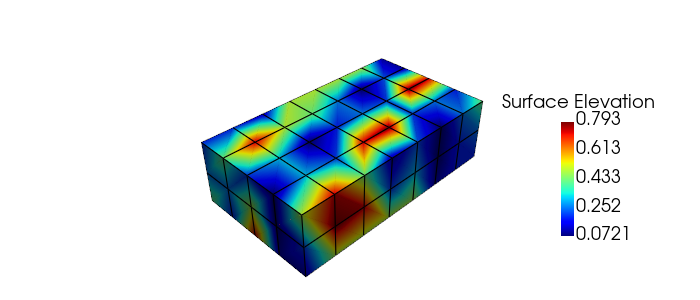

In [5]:
sargs = dict(vertical=True, title="Surface Elevation", width=0.05, position_x=0.8, position_y=0.2 )
pl = pv.Plotter(window_size=[700, 300])                ; pl.add_mesh(grid   ,show_edges=True,scalar_bar_args=sargs,cmap='jet')                          ; pl.show()

#file_path = os.path.join(os.getcwd(), 'Paraview')     ; grid.save(os.path.join(file_path, "volume_data.vti"), grid)    ; grid.save("volume_data.vti")  ; grid